### Data Load

In [1]:
# ============================================================
# Configure PDF Directory
# ============================================================

from pathlib import Path

DATA_DIR = Path("data")
pdf_files = sorted(DATA_DIR.glob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files:")
for pdf in pdf_files:
    print(f" - {pdf.name}")

Found 5 PDF files:
 - 01_Employee_Handbook.pdf
 - 02_Organization_Structure.pdf
 - 03_Employee_Directory.pdf
 - 04_Project_Portfolio.pdf
 - 05_Client_Profiles.pdf


In [2]:
# Load PDF Documents

from langchain_community.document_loaders import PyPDFLoader


documents = []

for pdf_path in pdf_files:
    print(f"Loading: {pdf_path.name}")
    
    loader = PyPDFLoader(str(pdf_path))
    documents.extend(loader.load())
    
    

print("\n" + "=" * 60)
print(f"Total PDF Files : {len(pdf_files)}")
print(f"Total Pages: {len(documents)}")
print("=" * 60)

C:\Users\User\AppData\Local\Temp\ipykernel_30368\3080520978.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Loading: 01_Employee_Handbook.pdf
Loading: 02_Organization_Structure.pdf
Loading: 03_Employee_Directory.pdf
Loading: 04_Project_Portfolio.pdf
Loading: 05_Client_Profiles.pdf

Total PDF Files : 5
Total Pages: 98


In [3]:
# Preview Loaded Documents

print(f"Source : {documents[0].metadata['source']}")
print(f"Page   : {documents[0].metadata['page']}")
print("-" * 60)
print(documents[0].page_content[:1000])

Source : data\01_Employee_Handbook.pdf
Page   : 0
------------------------------------------------------------
NEXATECH SOLUTIONS
Cloud · AI · Cyber Security · Data Engineering
Employee Handbook
Policies, Benefits & Ways of Working
Document Number NTS-HR-001
Version 6.2
Effective Date January 15, 2026
Document Owner Grace Okafor, Director of People Operations 
(Human Resources)
Classification Internal Use Only
NexaTech Solutions — Internal Use Only   |   Page 1 of 8


### Document Chunking

In [4]:
# Split Documents into Chunks


from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""]
)

split_documents = text_splitter.split_documents(documents)

print("=" * 60)
print(f"Original Documents : {len(documents)}")
print(f"Total Chunks       : {len(split_documents)}")
print("=" * 60)

Original Documents : 98
Total Chunks       : 158


### Define the LLM

In [5]:
import os

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


load_dotenv()


llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0
)

print("OpenAI Model Loaded Successfully")



OpenAI Model Loaded Successfully


### Graph Building

In [6]:
split_documents

[Document(metadata={'producer': 'LibreOffice 24.2', 'creator': 'Writer', 'creationdate': '2026-07-30T03:34:56+00:00', 'author': 'Un-named', 'source': 'data\\01_Employee_Handbook.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='NEXATECH SOLUTIONS\nCloud · AI · Cyber Security · Data Engineering\nEmployee Handbook\nPolicies, Benefits & Ways of Working\nDocument Number NTS-HR-001\nVersion 6.2\nEffective Date January 15, 2026\nDocument Owner Grace Okafor, Director of People Operations \n(Human Resources)\nClassification Internal Use Only\nNexaTech Solutions — Internal Use Only   |   Page 1 of 8'),
 Document(metadata={'producer': 'LibreOffice 24.2', 'creator': 'Writer', 'creationdate': '2026-07-30T03:34:56+00:00', 'author': 'Un-named', 'source': 'data\\01_Employee_Handbook.pdf', 'total_pages': 8, 'page': 1, 'page_label': '2'}, page_content='NexaTech Solutions — Employee Handbook (NTS-HR-001)\nTable of Contents\nNexaTech Solutions — Internal Use Only   |   Page 2 of 8'),
 

In [7]:
# Convert the Documents into Graph Documents

from langchain_experimental.graph_transformers import LLMGraphTransformer


llm_transformer = LLMGraphTransformer(llm=llm)

graph_documents = llm_transformer.convert_to_graph_documents(
    split_documents[:20]
)


print("=" * 60)
print(f"Graph Documents Created : {len(graph_documents)}")
print("=" * 60)

C:\Users\User\AppData\Local\Temp\ipykernel_30368\3426656194.py:3: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.graph_transformers import LLMGraphTransformer


Graph Documents Created : 20


In [8]:
# Preview Extracted Graph

graph = graph_documents[0]

print("=" * 60)
print("NODES")
print("=" * 60)


for node in graph.nodes:
    print(node)
    
    
print("\n" + "=" * 60)
print("RELATIONSHIPS")
print("=" * 60)


for relationship in graph.relationships:
    print(relationship)

NODES
id='Nexatech Solutions' type='Organization' properties={}
id='Cloud' type='Concept' properties={}
id='Ai' type='Concept' properties={}
id='Cyber Security' type='Concept' properties={}
id='Data Engineering' type='Concept' properties={}
id='Employee Handbook' type='Document' properties={}
id='Nts-Hr-001' type='Document' properties={}
id='Version 6.2' type='Document' properties={}
id='January 15, 2026' type='Date' properties={}
id='Grace Okafor' type='Person' properties={}
id='Director Of People Operations' type='Role' properties={}
id='Internal Use Only' type='Classification' properties={}

RELATIONSHIPS
source=Node(id='Nexatech Solutions', type='Organization', properties={}) target=Node(id='Cloud', type='Concept', properties={}) type='FOCUS' properties={}
source=Node(id='Nexatech Solutions', type='Organization', properties={}) target=Node(id='Ai', type='Concept', properties={}) type='FOCUS' properties={}
source=Node(id='Nexatech Solutions', type='Organization', properties={}) targ

In [9]:
# Preview Multiple Graph Documents


for index, graph in enumerate(graph_documents[:3], start=1):
    print("\n" + "=" * 70)
    print(f"Graph Document {index}")
    print("=" * 70)

    print(f"Nodes         : {len(graph.nodes)}")
    print(f"Relationships : {len(graph.relationships)}")


Graph Document 1
Nodes         : 12
Relationships : 11

Graph Document 2
Nodes         : 6
Relationships : 5

Graph Document 3
Nodes         : 19
Relationships : 16


In [10]:
# Connect to Neo4j

from neo4j import GraphDatabase

URI = "bolt://localhost:7687"
USERNAME = "neo4j"
PASSWORD = "GraphRAG123"

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

print("✅ Connected to Neo4j")

✅ Connected to Neo4j


### Graph DB Ingestion

In [11]:
from neo4j import GraphDatabase


def sanitize(text: str) -> str:
    return (
        text.upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "_")
    )


def store_graph_documents(driver, graph_documents):
    with driver.session() as session:
        for graph_document in graph_documents:

            # --------------------------------------------------
            # Store Nodes
            # --------------------------------------------------

            for node in graph_document.nodes:
                label = sanitize(node.type)
                properties = {"id": node.id, "name": node.id}

                if hasattr(node, "properties"):
                    properties.update(node.properties)

                query = f"""
                        MERGE (n:Entity:{label} {{id: $id}})
                        SET n += $properties
                        """
                session.run(query, id=node.id, properties=properties)

            # --------------------------------------------------
            # Store Relationships
            # --------------------------------------------------

            for relationship in graph_document.relationships:
                source_label = sanitize(relationship.source.type)
                target_label = sanitize(relationship.target.type)
                relationship_type = sanitize(relationship.type)
                properties = {}

                if hasattr(relationship, "properties"):
                    properties.update(relationship.properties)

                query = (
                    f"MATCH (a:{source_label} {{id: $source}}) "
                    f"MATCH (b:{target_label} {{id: $target}}) "
                    f"MERGE (a)-[r:{relationship_type}]->(b) "
                    f"SET r += $properties"
                )

                session.run(
                    query,
                    source=relationship.source.id,
                    target=relationship.target.id,
                    properties=properties,
                )

    print("✅ Graph stored successfully.")

In [12]:
# Store Graph into Neo4j

store_graph_documents(
    driver=driver,
    graph_documents=graph_documents
)

print("✅ Graph successfully ingested into Neo4j.")

✅ Graph stored successfully.
✅ Graph successfully ingested into Neo4j.


### Graph DB Extraction

In [13]:
# User Question

question = "Who is working on the Employee Directory project?"
question = "Tell me about Cyber Security?"

In [14]:
# Retrieve Matching Graph Context


from neo4j import GraphDatabase


query = """
MATCH (n)-[r]-(m)

WHERE toLower($question) CONTAINS toLower(n.name)
   OR toLower(n.name) CONTAINS toLower($question)

RETURN
    labels(n) AS source_type,
    n.name AS source,
    type(r) AS relationship,
    labels(m) AS target_type,
    m.name AS target

LIMIT 50
"""



with driver.session() as session:
    
    result = session.run(
        query,
        question=question
    )
    
    
    graph_context = []
    
    
    for record in result:
        
        graph_context.append(
            f"{record['source']}"
            f"-[{record['relationship']}]->"
            f"{record['target']}"
        )
        
print("\n".join(graph_context))

Cyber Security-[FOCUS]->Nexatech Solutions
Cyber Security-[HAS_DEPARTMENT]->Nexatech Solutions


In [15]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are a helpful assistant.

Answer ONLY using the graph context.

Graph Context:
{context}

Question:
{question}
"""

response = llm.invoke(prompt)

print(response.content)

Cyber Security is a focus and has a department within Nexatech Solutions.


### 🔹 Case 1: LLM Entity Extraction + Direct Entity Matching

Instead of sending the complete user question to Neo4j, we first use the LLM to extract the important entities and then directly match those entities against the entity names stored in Neo4j.

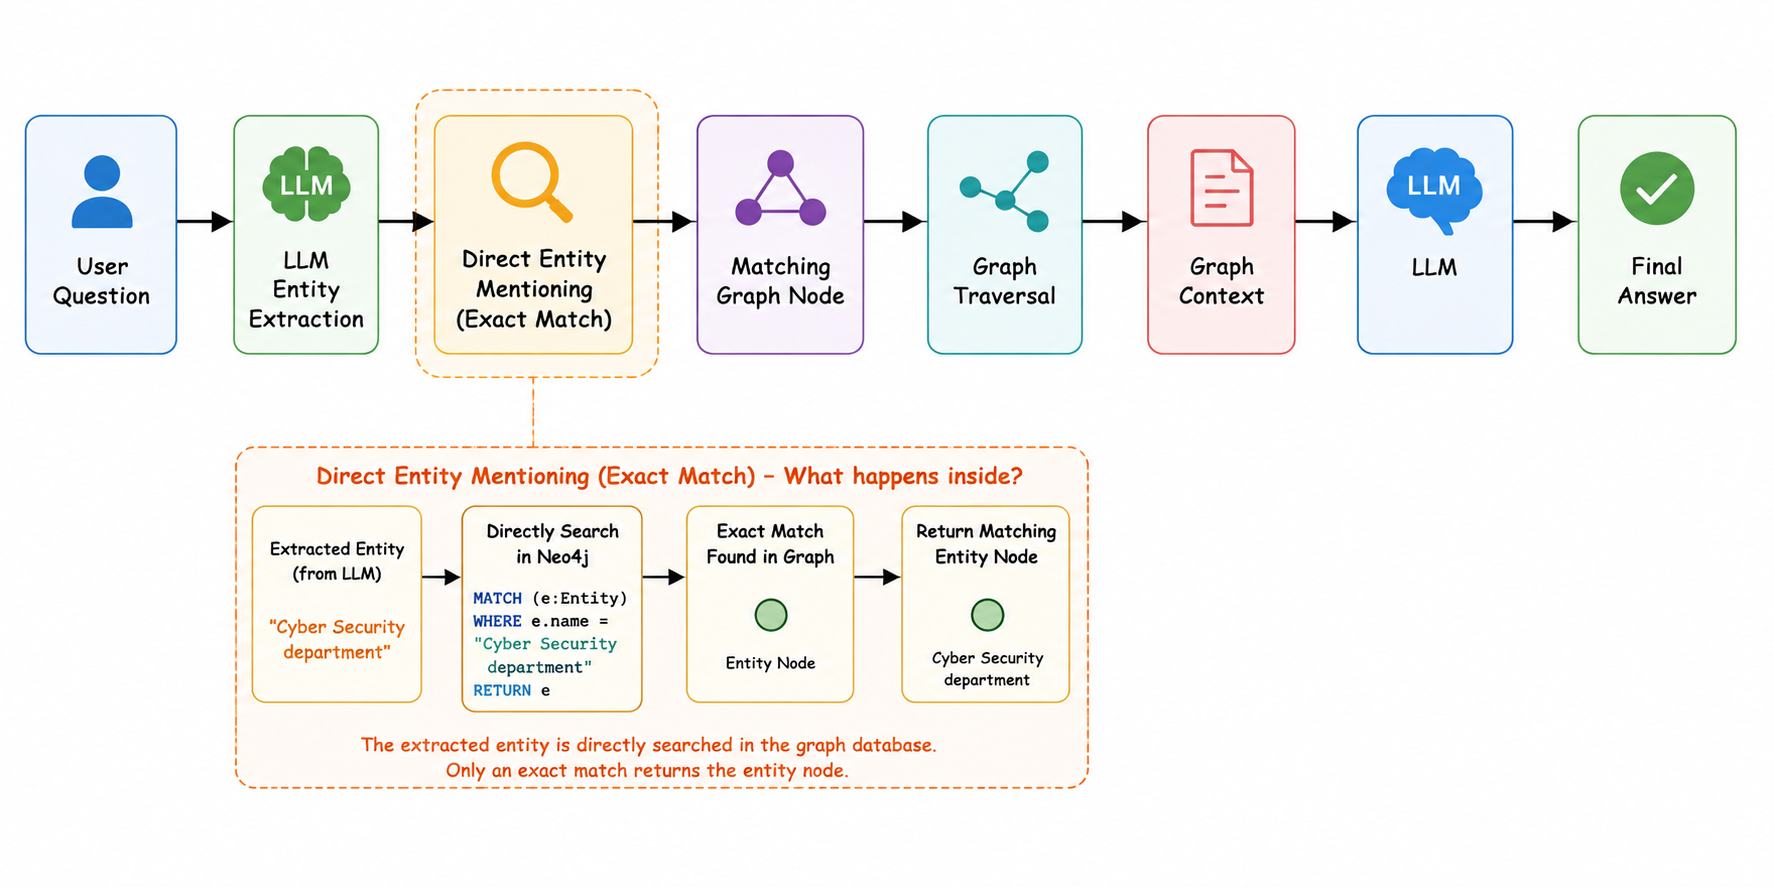

Entity Extraction

In [16]:
# ============================================================
# User Question
# ============================================================

question = "Who is working on the Employee Directory project?"
question = "Tell me about Cyber Security"

In [17]:
# ============================================================
# Extract Entities from User Question
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class EntityExtraction(BaseModel):
    entities: List[str] = Field(
        description="List of important entities mentioned in the question."
    )


entity_llm = llm.with_structured_output(EntityExtraction)

question = "Tell me about Cyber Security"

entity_result = entity_llm.invoke(f"""
Extract all important entities from the following question.

Question:
{question}
""")

print("=" * 60)
print("Extracted Entities")
print("=" * 60)

print(entity_result.entities)

Extracted Entities
['Cyber Security']


In [18]:
entity_result

EntityExtraction(entities=['Cyber Security'])

**Retrieved**

In [19]:
# ============================================================
# Retrieve Relevant Graph Context
# ============================================================
cypher_query = """
MATCH path = (n)-[*1..2]-(m)

WHERE toLower(n.name) = toLower($entity)

UNWIND relationships(path) AS r
UNWIND nodes(path) AS node

RETURN DISTINCT
    startNode(r).name AS source,
    type(r) AS relationship,
    endNode(r).name AS target
LIMIT 100
"""

graph_context = []

with driver.session() as session:

    for entity in ['Cyber Secuuriity']:

        result = session.run(
            cypher_query,
            entity=entity
        )

        for record in result:

            graph_context.append(
                f"{record['source']} "
                f"-[{record['relationship']}]-> "
                f"{record['target']}"
            )

print("=" * 60)
print("Retrieved Graph Context")
print("=" * 60)

print("\n".join(graph_context))

Retrieved Graph Context



**Generation**

In [20]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are an AI assistant.

Answer ONLY using the graph context.

If the answer is not available, say so.

==========================
Graph Context
==========================

{context}

==========================
Question
==========================

{question}
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
I'm sorry, but the information about Cyber Security is not available in the provided graph context.


### 🔹 Case 2: LLM Entity Extraction + Partial Entity Matching

We keep the LLM-based entity extraction from Case 1, but instead of requiring an exact entity-name match, we use partial matching to find relevant entities in Neo4j.

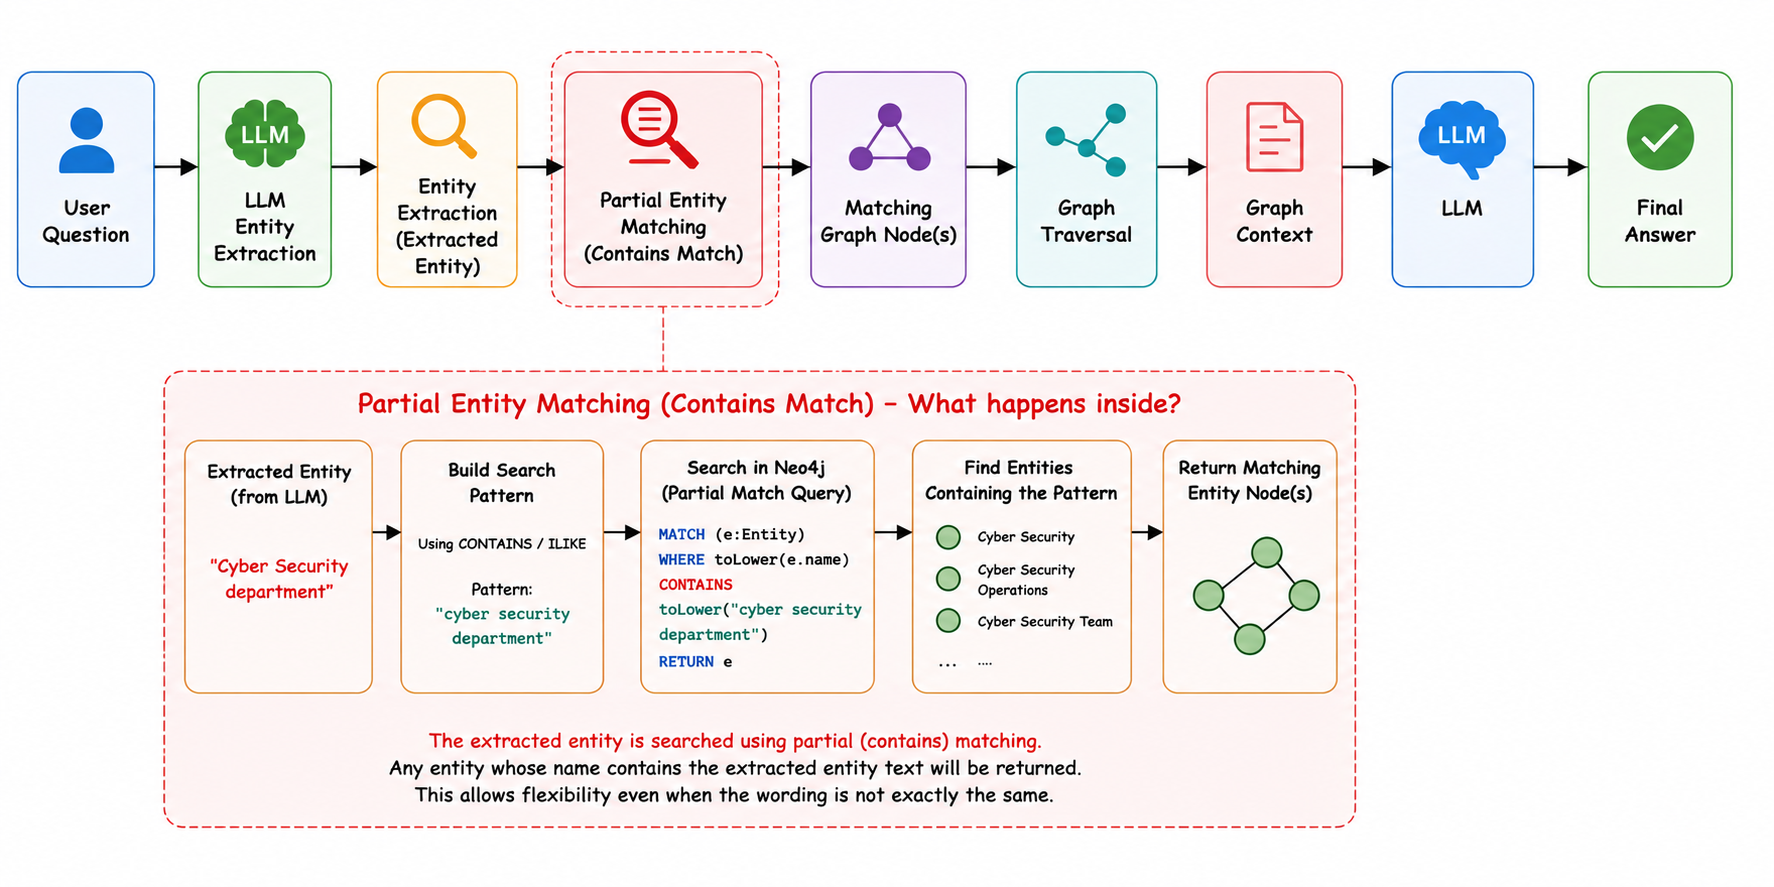

In [21]:
# ============================================================
# Retrieve Relevant Graph Context from Neo4j
# ============================================================

cypher_query = """
MATCH (n)-[r]-(m)

WHERE ANY(keyword IN $keywords
          WHERE toLower(n.name) CONTAINS keyword)

RETURN DISTINCT
    labels(n) AS source_label,
    n.name AS source,
    type(r) AS relationship,
    labels(m) AS target_label,
    m.name AS target

LIMIT 100
"""

graph_context = []

with driver.session() as session:

    for entity in entity_result.entities:

        # Split extracted entity into keywords
        keywords = [
            word.strip()
            for word in entity.lower().split()
            if len(word.strip()) > 2
        ]

        print(f"\nSearching for Entity : {entity}")
        print(f"Keywords             : {keywords}")

        result = session.run(
            cypher_query,
            keywords=keywords
        )

        records = list(result)

        print(f"Matches Found        : {len(records)}")

        for record in records:

            graph_context.append(
                f"{record['source']} "
                f"-[{record['relationship']}]-> "
                f"{record['target']}"
            )

print("\n" + "=" * 60)
print("Retrieved Graph Context")
print("=" * 60)

print("\n".join(graph_context))


Searching for Entity : Cyber Security
Keywords             : ['cyber', 'security']
Matches Found        : 11

Retrieved Graph Context
Cyber Security -[FOCUS]-> Nexatech Solutions
Information Security & Acceptable Use -[INCLUDES]-> Master Client Confidentiality Agreement
Information Security & Acceptable Use -[HAS_POLICY]-> Nexatech Solutions
Information Security & Acceptable Use -[REFERENCES]-> Master Client Confidentiality Agreement
Information Security & Acceptable Use -[INCLUDES]-> Data Classification
Information Security & Acceptable Use -[HAS_POLICY]-> Nexatech
Cyber Security Security Operations Center -[LOCATED_IN]-> Bangalore
Cyber Security Security Operations Center -[LOCATED_IN]-> London
Cyber Security Team -[USES]-> Workday
Cyber Security Team -[USES]-> Workday
Cyber Security -[HAS_DEPARTMENT]-> Nexatech Solutions


In [22]:
question

'Tell me about Cyber Security'

In [23]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are an AI assistant.

Answer ONLY using the graph context.

If the answer is not available, say so.

==========================
Graph Context
==========================

{context}

==========================
Question
==========================

{question}
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
Cyber Security is focused on Nexatech Solutions and has a department within Nexatech Solutions. Additionally, the Cyber Security Security Operations Center is located in Bangalore and London.


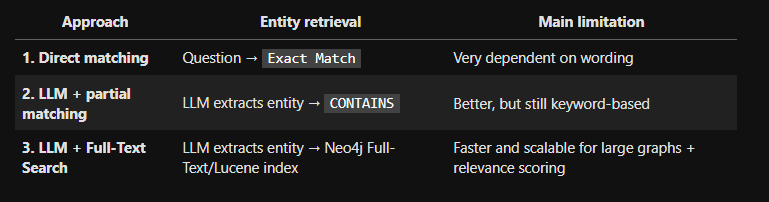

### 🔹Case 3: LLM Entity Extraction + Neo4j Full-Text Search


In this approach, we first use the LLM to extract the important entities from the user's question. Instead of using exact or basic partial string matching, we use Neo4j Full-Text Search to find the most relevant entities from the graph.

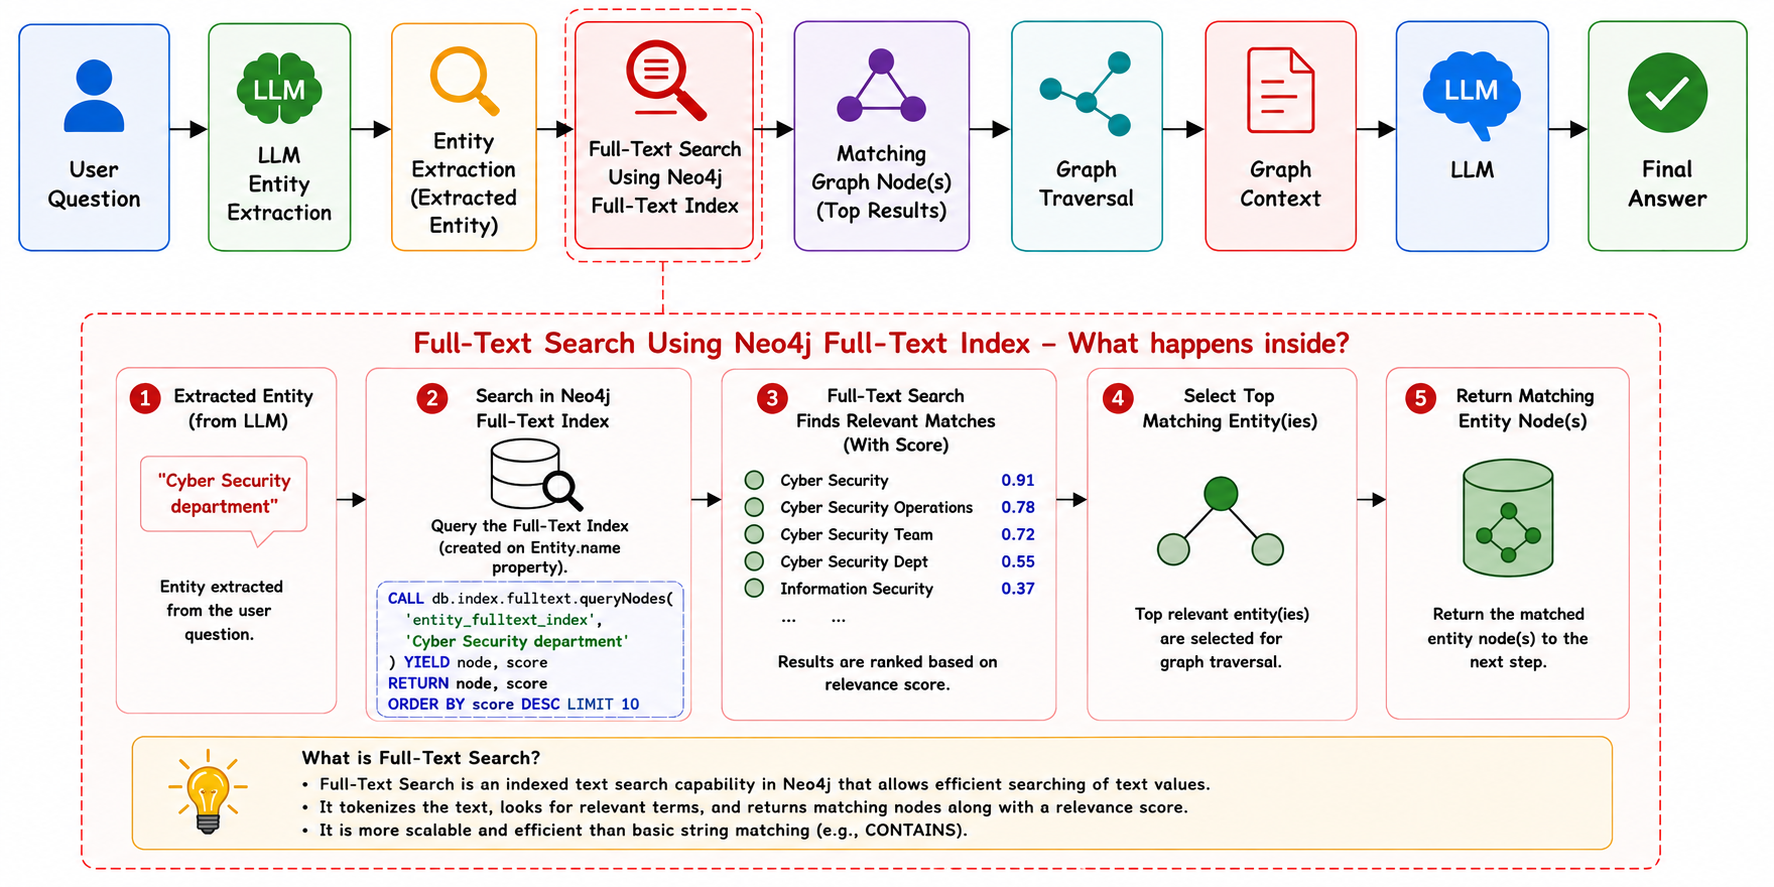

In [24]:
# ============================================================
# Create Full-Text Index (If Not Exists)
# ============================================================

CHECK_INDEX_QUERY = """
SHOW INDEXES
YIELD name
WHERE name = 'entity_index'
RETURN count(*) AS count
"""

CREATE_INDEX_QUERY = """
CREATE FULLTEXT INDEX entity_index
FOR (n:Entity)
ON EACH [n.name]
"""

with driver.session() as session:

    result = session.run(CHECK_INDEX_QUERY).single()

    if result["count"] == 0:

        session.run(CREATE_INDEX_QUERY)

        print("✅ Full-Text Index created successfully.")

    else:

        print("ℹ️ Full-Text Index already exists.")

✅ Full-Text Index created successfully.


In [25]:
# ============================================================
# User Question
# ============================================================

question = "Tell me about Cyber Security"

# ============================================================
# Extract Entities
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class EntityExtraction(BaseModel):
    entities: List[str] = Field(
        description="List of entities mentioned in the user question."
    )


entity_llm = llm.with_structured_output(EntityExtraction)

entity_result = entity_llm.invoke(f"""
Extract all important entities from the question.

Question:
{question}
""")

print("=" * 60)
print("Extracted Entities")
print("=" * 60)

print(entity_result.entities)


# ============================================================
# Full-Text Search
# ============================================================

FULLTEXT_QUERY = """
CALL db.index.fulltext.queryNodes(
    'entity_index',
    $entity
)
YIELD node, score

RETURN
    node.name AS name,
    labels(node) AS labels,
    score

ORDER BY score DESC
LIMIT 5
"""

matched_entities = []

with driver.session() as session:

    for entity in entity_result.entities:

        print(f"\nSearching : {entity}")

        result = session.run(
            FULLTEXT_QUERY,
            entity=entity
        )

        records = list(result)

        if not records:
            print("No match found.")
            continue

        for record in records:

            print(
                f"{record['name']} "
                f"(Score : {record['score']:.2f})"
            )

            matched_entities.append(record["name"])

Extracted Entities
['Cyber Security']

Searching : Cyber Security
Cyber Security (Score : 3.64)
Cyber Security (Score : 3.64)
Cyber Security Team (Score : 3.05)
Cyber Security Security Operations Center (Score : 2.91)
Information Security & Acceptable Use (Score : 1.28)


In [26]:
# ============================================================
# Retrieve Graph Context for Matched Entities
# ============================================================

GRAPH_QUERY = """
MATCH (n)-[r]-(m)
WHERE n.name IN $entities

RETURN DISTINCT
    n.name AS source,
    type(r) AS relationship,
    m.name AS target
LIMIT 100
"""

graph_context = []

with driver.session() as session:

    result = session.run(
        GRAPH_QUERY,
        entities=matched_entities
    )

    for record in result:

        graph_context.append(
            f"{record['source']} "
            f"-[{record['relationship']}]-> "
            f"{record['target']}"
        )

print("=" * 60)
print("Retrieved Graph Context")
print("=" * 60)

for item in graph_context:
    print(item)

Retrieved Graph Context
Cyber Security -[FOCUS]-> Nexatech Solutions
Information Security & Acceptable Use -[INCLUDES]-> Master Client Confidentiality Agreement
Information Security & Acceptable Use -[HAS_POLICY]-> Nexatech Solutions
Information Security & Acceptable Use -[REFERENCES]-> Master Client Confidentiality Agreement
Information Security & Acceptable Use -[INCLUDES]-> Data Classification
Information Security & Acceptable Use -[HAS_POLICY]-> Nexatech
Cyber Security Security Operations Center -[LOCATED_IN]-> Bangalore
Cyber Security Security Operations Center -[LOCATED_IN]-> London
Cyber Security Team -[USES]-> Workday
Cyber Security -[HAS_DEPARTMENT]-> Nexatech Solutions


In [27]:
# ============================================================
# Generate Final Answer
# ============================================================

context = "\n".join(graph_context)

prompt = f"""
You are a GraphRAG assistant.

Answer the user's question using only the information
provided in the graph context.

If the graph context does not contain enough information,
say that the information is not available in the knowledge graph.

-------------------- Graph Context --------------------

{context}

---------------------- Question ------------------------

{question}

---------------------------------------------------------

Provide a concise and factual answer.
"""

response = llm.invoke(prompt)

print("=" * 60)
print("Final Answer")
print("=" * 60)

print(response.content)

Final Answer
Cyber Security at Nexatech Solutions focuses on various aspects including the Security Operations Center located in Bangalore and London. The Cyber Security team uses Workday and is part of the Nexatech Solutions department.


### Next Advancements for GraphRAG

- Hybrid GraphRAG — Combine vector search with graph traversal.
- Neo4j Vector Index — Use embeddings for semantic retrieval.
- Better Entity Resolution — Handle synonyms, abbreviations, and ambiguous entities.
- Multi-hop Reasoning — Traverse multiple levels of relationships.
- Chunk + Graph Linking — Connect source document chunks to graph entities.
- Relationship-aware Retrieval — Retrieve the most relevant graph paths.
- Reranking — Rerank retrieved nodes, paths, and chunks before generation.
- Source Citations — Return the original PDF/page/chunk supporting each answer.
- Hybrid Search — Combine keyword, vector, and graph-based retrieval.
- Evaluation — Compare Traditional RAG vs GraphRAG vs Hybrid GraphRAG.